# Pre-processing the dataset:

In [62]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"

df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")


# Fixed Epoch: 01/01/2026
REF_DATE = 1767225600 
ONE_YEAR = 365 * 86400

df["recency_score"] = 1 / ((REF_DATE - df["mod_time_unix"]) / ONE_YEAR + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)
df["path_depth"] = df["path"].apply(lambda p: p.count("/") + p.count("\\"))

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=2048,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(4, 4),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

df

,filename,path,extension,size_bytes,mod_time_unix,source_user,source_type,label_finance,label_hr,label_it,label_general,recency_score,size_logged,name_len,path_len,path_depth
0,MDPI-WINDEX Rpt.docx,C:\Users\omiller\Desktop\Writing\Windex\Docx,.docx,576716,1.744225e+09,omiller,govdoc_real,0,0,0,0,0.578252,13.265107,20,44,6
1,README.md,\\wsl$\Debian\home\torreselaine\git\CSS.NLogEx...,.md,217,1.751013e+09,torreselaine,github_real,0,0,0,0,0.660455,5.384495,9,54,7
2,identity,C:\Users\martin05\Desktop\Coding\puroextremo.c...,NaN,64074,1.755964e+09,dev_injector,secret_injection,0,0,1,1,0.736856,11.067810,8,74,7
3,settings.py,C:\Work\Projects\Mixly_Arduino\mixly_arduino\b...,.py,1773,1.739566e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.532742,7.480992,11,102,11
4,17acad98.lib,C:\Work\Projects\opensplice\src\api\dcps\java\...,.lib,103820,1.735757e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.500537,11.550424,12,89,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5144,docker-compose.yml,C:\Users\wilsonspencer\Desktop\Coding\carbon-a...,.yml,47672,1.680493e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.266648,10.772120,18,187,22
5145,cathycvr.docx,Z:\HR\Recruiting\Reqs\2023\Docx\Cathycvr,.docx,5179965,1.645951e+09,ybrown,govdoc_real,0,0,0,0,0.206374,15.460309,13,40,6
5146,ACKDisabledSplitViewDelegate.h,C:\Work\Projects\AndromedaIDE\AndromedaCodeKit,.h,1449,1.747482e+09,devops,github_real,0,0,0,0,0.614977,7.279319,30,46,4
5147,QuickTimeVRLocalized.qtr,C:\Program Files\QuickTime\QTSystem\QuickTimeV...,.qtr,29696,1.749900e+09,jo,system_noise,0,0,0,0,0.645421,10.298801,24,69,5


# Training:

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target-specific valuable extensions
target_extension_map = {
    "label_finance": [".xlsx", ".xls", ".csv", ".pdf", ".accp", ".pptx"],
    "label_hr": [".docx", ".doc", ".rtf", ".pdf", ".xlsx", ".xls"],
    "label_it": [".pem",".key",".kdbx",".p12",".ovpn",".private",".wallet",".sql",".env"]
}

# Add "label_general" after defining the other labels
target_extension_map["label_general"] = list(
    set(
        target_extension_map["label_finance"]
        + target_extension_map["label_hr"]
        + target_extension_map["label_it"]
    )
)
common_dev_junk = [".pyc", ".pyi", ".lcl", ".pyd", ".map", ".ts", ".js", ".spec", ".test.js",]

# Define target-specific junk extensions
target_junk_map = {
    "label_finance": [".class", ".java", ".cpp", ".obj", ".dll", ".exe"]
    + common_dev_junk,
    "label_hr": [".class", ".java", ".py", ".obj", ".dll", ".exe"] + common_dev_junk,
    "label_it": [".tmp", ".log", ".cache"]
    + [ext for ext in common_dev_junk if ext not in [".ts", ".js"]],
}

target_junk_map["label_general"] = list(
    set(
        target_junk_map["label_finance"]
        + target_junk_map["label_hr"]
        + target_junk_map["label_it"]
    )
)

target_configs = {
    "label_finance": {"C": 0.3, "weight": 4.0},
    "label_general": {"C": 0.3, "weight": 2.0},
    "label_hr":      {"C": 0.5, "weight": 4.0},
    "label_it":      {"C": 0.8, "weight": 12.0}
}

models_map = {}

for target, config in target_configs.items():

    # Prepare Data
    df_temp = df.copy()
    df_temp["valuable_ext"] = df_temp["extension"].isin(target_extension_map[target]).astype(int)
    df_temp["junk_ext"] = df_temp["extension"].isin(target_junk_map[target]).astype(int)

    # df_temp.to_csv("1.csv", index=False)

    # Create feature matrix X and target vector y for the current target
    numerical_features = df_temp[
        [
            "recency_score",
            "size_logged",
            "valuable_ext",
            "junk_ext",
            "name_len",
            "path_len",
            "path_depth",
        ]
    ].values
    X_target = hstack([numerical_features, filename_vectors, path_vectors])
    y_target = df_temp[target].values

    # Split Data
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_target, y_target, df_temp.index, test_size=0.2, random_state=42, stratify=y_target
    )

    # Train Model
    C = config["C"]
    model = LogisticRegression(solver="lbfgs", max_iter=1000,
                                C=C, class_weight={0: 1, 1: config['weight']})
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    print("Accuracy for", target, ":", accuracy_score(y_test, y_pred))
    print("\nClassification Report for c =", C, ", weight =", config['weight'], ", Bias =", model.intercept_[0], ":\n", classification_report(y_test, y_pred))

    models_map[target] = model

Accuracy for label_finance : 0.9805825242718447

Classification Report for c = 0.3 , weight = 4.0 , Bias = -4.51451439769483 :
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       994
           1       0.67      0.89      0.76        36

    accuracy                           0.98      1030
   macro avg       0.83      0.94      0.88      1030
weighted avg       0.98      0.98      0.98      1030

Accuracy for label_general : 0.9427184466019417

Classification Report for c = 0.3 , weight = 2.0 , Bias = -4.939218449655638 :
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       873
           1       0.82      0.80      0.81       157

    accuracy                           0.94      1030
   macro avg       0.89      0.89      0.89      1030
weighted avg       0.94      0.94      0.94      1030

Accuracy for label_hr : 0.974757281553398

Classification Report for c = 0.5 , weight = 4

# Display results

Top results for model targeting label_finance:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
192,2023 Budget Final Memo to Board_v3.docx,Z:\Finance\General_Ledger\2023,.docx,83886,39,30,3,1.765621e+09,govdoc_real,1,0.988852
525,testcomprecall.docx,Z:\HR\Payroll\Cycles\2025\Testcomprecall,.docx,356515,19,40,5,1.752280e+09,govdoc_real,1,0.986589
850,Ephedra Cases Levey Federal Court Civil Penalt...,Z:\HR\Payroll\Cycles\2024,.docx,83886,64,25,4,1.744719e+09,govdoc_real,1,0.985851
590,NIA TASK Budget Proposal 4 23 08.docx,C:\Users\lelaurie\OneDrive - Corp\Finance\Repo...,.docx,41943,37,51,5,1.764130e+09,govdoc_real,1,0.985122
791,Budget-Week-2.028.docx,Z:\Finance\General_Ledger\2024\Budget,.docx,314572,22,37,4,1.746572e+09,govdoc_real,1,0.984755
920,ISOLATION OF NUCLEAR DNA FROM Arabidopsis lyra...,Z:\HR\Payroll\Cycles\2023\Arabidopsis,.docx,325058,64,37,5,1.758784e+09,govdoc_real,1,0.983446
460,Bluebook NMFS Summary & Detail FY 2025 Preside...,Z:\Finance\General_Ledger\2024,.xlsx,52428,82,30,3,1.743162e+09,govdoc_real,1,0.978289
203,LOCAL COMPENSATION PLAN WITH GUIDELINES FOR US...,Z:\HR\Payroll\Cycles\2025,.docx,52428,59,25,4,1.749690e+09,govdoc_real,1,0.974570
26,proton_budget.xlsx,Z:\Finance\General_Ledger\2024,.xlsx,31457,18,30,3,1.763497e+09,govdoc_real,1,0.974457
221,accomp-novdec08.docx,Z:\HR\Payroll\Cycles\2025\Docx,.docx,209715,20,30,5,1.740430e+09,govdoc_real,1,0.972332


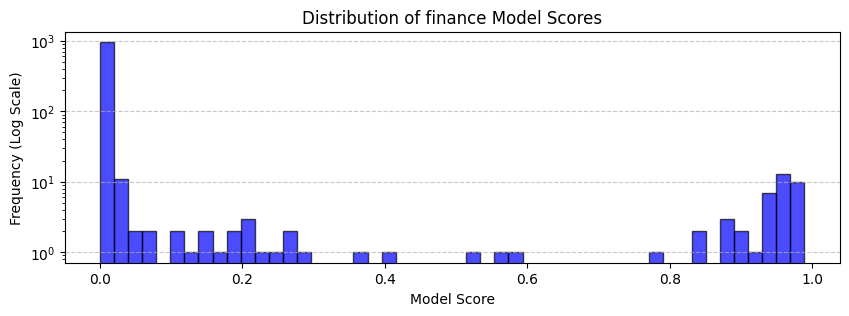

Top results for model targeting label_general:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
418,cert.pem,C:\Users\kathryngilbert\AppData\Local\Packages...,.pem,140251,8,154,19,1.760646e+09,secret_injection,1,0.994155
186,config.py,C:\Users\karenbarnes\source\repos\config,.py,2495,9,40,5,1.760636e+09,secret_injection,1,0.993606
382,Recruitment_Funnel_2023_FINAL.xlsx,Z:\HR\Recruiting\Reports\Archive,.xlsx,157286,34,32,4,1.765183e+09,chatGPT_HR,1,0.982284
465,LivestockFinalFormatted0113sections.rtf,Z:\HR\Payroll\Cycles\2025,.rtf,62914,39,25,4,1.754949e+09,govdoc_real,1,0.975283
851,nuget.config,\\wsl$\Ubuntu\home\config,.config,2157,12,25,5,1.759423e+09,secret_injection,1,0.971833
26,proton_budget.xlsx,Z:\Finance\General_Ledger\2024,.xlsx,31457,18,30,3,1.763497e+09,govdoc_real,1,0.965631
200,.env.production,C:\Users\ricardo01\AppData\Local,.production,2659,15,32,4,1.759694e+09,secret_injection,1,0.965076
805,wallet.dat,C:\Users\wilsonspencer\Desktop\Code_Review\rpm...,.dat,67237,10,73,7,1.763207e+09,secret_injection,1,0.959773
802,database.yml,C:\Users\pricebrian\source\repos,.yml,892,12,32,4,1.759924e+09,secret_injection,1,0.958340
845,secrets.py,C:\Users\bryanterin\Downloads\wekan-master\config,.py,3038,10,49,5,1.735815e+09,secret_injection,1,0.955454


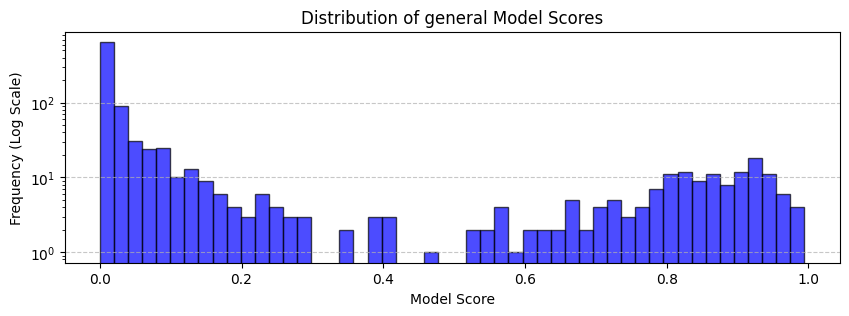

Top results for model targeting label_hr:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
382,Recruitment_Funnel_2023_FINAL.xlsx,Z:\HR\Recruiting\Reports\Archive,.xlsx,157286,34,32,4,1.765183e+09,chatGPT_HR,1,0.985738
404,R1 Parent and Screener-final-parent.pdf,Z:\HR\Recruiting\Reqs\2025\Final,.pdf,346030,39,32,5,1.761200e+09,govdoc_real,1,0.979976
545,2023 Seasonal Fire Hiring Flyer.doc,Z:\HR\Recruiting\Reqs\2024\Fire\Hiring,.doc,387973,35,38,6,1.757668e+09,govdoc_real,1,0.974119
680,Hochler Subdivisions Low Effect Screening Form...,Z:\HR\Recruiting\Reqs\2025\Screening\Screening,.doc,20971,64,46,6,1.745055e+09,govdoc_real,1,0.972805
645,Recruitment_Status_Report.xlsx,Z:\HR\Recruiting\Reqs\2024\Reports,.xlsx,31457,30,34,5,1.633042e+09,chatGPT_HR,0,0.966758
182,02cv2807_bluebeard_opn.docx,Z:\HR\Recruiting\Reqs\2025,.docx,94371,27,26,4,1.765258e+09,govdoc_real,1,0.965458
880,Candidate_Profile_April2024.pdf,Z:\HR\Recruiting\Reqs\2024\Profiles,.pdf,10485,31,35,5,1.762030e+09,chatGPT_HR,1,0.964609
891,TABLE 3.2 Screen_Perched rev3.doc,Z:\HR\Recruiting\Reqs\2024\Screen,.doc,20971,33,33,5,1.751096e+09,govdoc_real,1,0.963910
145,Trans--RIF Resume Instructions.docx,C:\Users\goodjeffrey\Documents\HR\Talent_Acqui...,.docx,94371,35,70,7,1.758688e+09,govdoc_real,1,0.961735
96,04cv0016_council_clarify_3.docx,Z:\HR\Recruiting\Reqs\2025\Clarify,.docx,20971,31,34,5,1.766793e+09,govdoc_real,1,0.948980


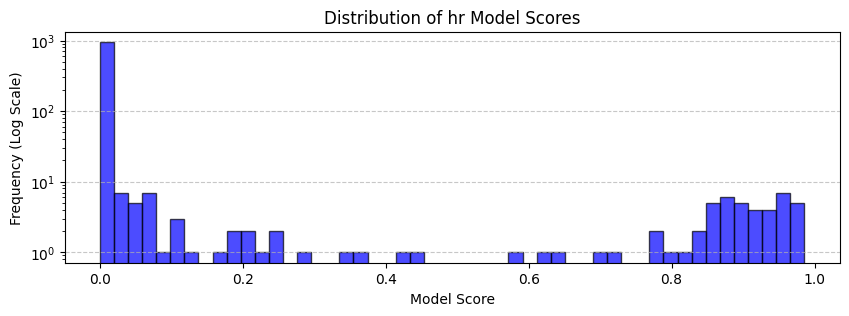

Top results for model targeting label_it:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
418,cert.pem,C:\Users\kathryngilbert\AppData\Local\Packages...,.pem,140251,8,154,19,1.760646e+09,secret_injection,1,0.998348
188,client.ovpn,C:\Users\sandraedwards\Dev\vaca\examples\Timers,.ovpn,41595,11,47,6,1.750229e+09,secret_injection,1,0.997945
851,nuget.config,\\wsl$\Ubuntu\home\config,.config,2157,12,25,5,1.759423e+09,secret_injection,1,0.997385
802,database.yml,C:\Users\pricebrian\source\repos,.yml,892,12,32,4,1.759924e+09,secret_injection,1,0.995052
205,wp-config.php,C:\Users\scottcampbell\Desktop\Coding\config,.php,2225,13,44,5,1.756417e+09,secret_injection,1,0.992264
805,wallet.dat,C:\Users\wilsonspencer\Desktop\Code_Review\rpm...,.dat,67237,10,73,7,1.763207e+09,secret_injection,1,0.991228
692,key.pem,C:\Users\joshua86\Dev\OpenFOAM-1.6-ext\src\Ope...,.pem,105166,7,96,11,1.740531e+09,secret_injection,1,0.989019
186,config.py,C:\Users\karenbarnes\source\repos\config,.py,2495,9,40,5,1.760636e+09,secret_injection,1,0.988860
845,secrets.py,C:\Users\bryanterin\Downloads\wekan-master\config,.py,3038,10,49,5,1.735815e+09,secret_injection,1,0.987811
1017,config.py,C:\Users\eric12\Desktop\Coding,.py,2911,9,30,4,1.766517e+09,secret_injection,1,0.987615


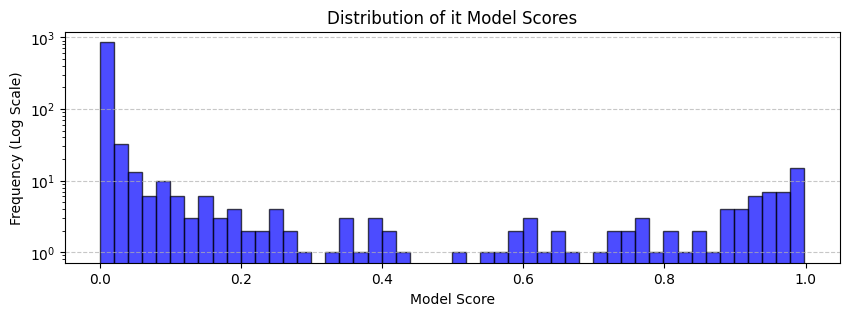

In [64]:
import matplotlib.pyplot as plt

for target, model in models_map.items():
    print(f"Top results for model targeting {target}:")

    # Get test set predictions
    y_test = df.loc[idx_test][target].values
    y_scores = model.predict_proba(X_test)[:, 1]

    results = pd.DataFrame(
        {
            "filename": df.loc[idx_test]["filename"].values,
            "filepath": df.loc[idx_test]["path"].values,
            "extension": df.loc[idx_test]["extension"].values,
            "size_bytes": df.loc[idx_test]["size_bytes"].values,
            "name_len": df.loc[idx_test]["name_len"].values,
            "path_len": df.loc[idx_test]["path_len"].values,
            "path_depth": df.loc[idx_test]["path_depth"].values,
            "mod_time_unix": df.loc[idx_test]["mod_time_unix"].values,
            "source_label": df.loc[idx_test]["source_type"].values,
            "actual_label": y_test,
            "model_score": y_scores,
        }
    )

    # Sort and slice the results
    sorted_results = results.sort_values(by="model_score", ascending=False)
    display(sorted_results[:10])

    # Plot the distribution of model scores
    plt.figure(figsize=(10, 3))
    plt.hist(
        results["model_score"], bins=50, color="blue", alpha=0.7, edgecolor="black"
    )
    plt.yscale("log")  # Set y-axis to log scale
    plt.title(f"Distribution of {target.split('_')[1]} Model Scores")
    plt.xlabel("Model Score")
    plt.ylabel("Frequency (Log Scale)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Exporting weights:

In [65]:
import os

output_path = f"../include/ModelWeights.h"

# 3. Ensure Directory Exists and Write
os.makedirs(os.path.dirname(output_path), exist_ok=True)

cpp_content = f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 

#include <vector>
#include <unordered_set>
#include <string>
"""

for target, model in models_map.items():

    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()
    title = target.split("_")[1].upper()
    cpp_content += f"""
const double {title}_MODEL_BIAS = {bias:.10f};

// recency score - size_logged - valuable_ext -  junk_ext - name_len - path_len - path_depth - filename features(2048) - path features(2048)
const std::vector<double> {title}_MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> {title}_HIGH_VAL_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_extension_map[target]])}}};

const std::unordered_set<std::wstring> {title}_JUNK_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_junk_map[target]])}}};
"""

with open(output_path, "w") as f:
    f.write(cpp_content)